<a href="https://colab.research.google.com/github/aapaul29/Distance-Recognition-SML1-/blob/aaryan-workspace/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SML Project 1 — Progressive Model Strategy**

**TA Advice**: *"Test simpler models, train them really well, then scale it up."*

Each tier is **well-tuned** on the validation set before escalating. The running `all_results` dict tracks every model for the final comparison.

This notebook works in both **VS Code (local)** and **Google Colab**.

| Tier | Model | Complexity |
|------|-------|------------|
| 0 | Naive (mean predictor) | Sanity floor |
| 1 | Ridge Regression | Linear |
| 2 | K-Nearest Neighbours | Non-linear, distance-based |
| 3 | Decision Tree | Non-linear, interpretable |
| 4 | Random Forest | Bagging ensemble |
| 5 | ExtraTrees | Randomised bagging |
| 6 | HGBR (light → tuned) | Sequential boosting |
| 7 | HGBC Soft Classifier | Classification-as-regression |
| 8 | MLP (PCA + MLP) | Neural baseline |
| 9 | Stacking Ensemble | Meta-ensemble |

## **1. <u>Environment Detection & Setup</u>**

In [1]:
import sys
import os

IN_COLAB = 'google.colab' in sys.modules
print(f"Running in {'Google Colab' if IN_COLAB else 'VS Code / local'}")

Running in VS Code / local




## **2. <u>Google Colab: Mount Drive & Navigate to Project</u>**
This cell only runs on Colab. Adjust `COLAB_PROJECT_PATH` to where you uploaded the project folder in your Google Drive.

In [2]:
# ---------------------------------------------------------------
# COLAB ONLY â€” skip if running locally
# Adjust this path to match your Google Drive folder structure.
COLAB_PROJECT_PATH = "/content/drive/MyDrive/Aaryan/Uni/BS-Mech-Eng-ETH-Zurich/2nd-year/Semester-4/Stochastics&Machine-Learning/Distance-Recognition-SML1-"
# ---------------------------------------------------------------

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd "$COLAB_PROJECT_PATH"
    print(f"Working directory: {os.getcwd()}")

    # Unzip data if not already extracted
    data_zip = os.path.join(COLAB_PROJECT_PATH, "data.zip")
    data_dir = os.path.join(COLAB_PROJECT_PATH, "data")
    if os.path.exists(data_zip) and not os.path.exists(data_dir):
        print("Unzipping data...")
        os.makedirs(data_dir, exist_ok=True)
        !unzip -q $data_zip -d $data_dir
        print("Done.")
    else:
        print("Data directory already exists or no zip found â€” skipping unzip.")
else:
    print("Local environment â€” no mounting needed.")

Local environment â€” no mounting needed.


## **3. <u>Auto-reload & Imports</u>**

In [3]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Memory

# Sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
    HistGradientBoostingClassifier,
    StackingRegressor,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import mean_absolute_error, r2_score

from utils import load_config, load_dataset, load_test_dataset, print_results, save_results

config = load_config()

[INFO]: Configs are loaded with: 
 {'data_dir': WindowsPath('data'), 'load_rgb': True, 'downsample_factor': 2}


In [4]:
if IN_COLAB:
    import shutil
    from pathlib import Path
    src = "/content/drive/MyDrive/Aaryan/Uni/BS-Mech-Eng-ETH-Zurich/2nd-year/Semester-4/Stochastics&Machine-Learning/Distance-Recognition-SML1-/data"
    dst = "/content/data"
    if not Path(dst).exists():
        print("Copying data to local Colab storage (faster I/O)...")
        shutil.copytree(src, dst)
        print("Done.")
    else:
        print("Local data already exists â€” skipping copy.")
    config["data_dir"] = Path(dst)
else:
    print("Running locally-copying not needed")

Running locally-copying not needed


In [5]:
# â”€â”€ Load Dataset â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
images, distances = load_dataset(config)
images = np.array(images)
print(f"[INFO]: Loaded {len(images)} images, shape: {images.shape}")

[INFO]: Loaded 3000 images, shape: (3000, 67500)


## <u>**Feature Engineering**</u>

In [6]:
def extract_hog_features(images_flat, img_height, img_width, n_channels,
                          pixels_per_cell=(16, 16), cells_per_block=(2, 2),
                          orientations=9):
    """
    HOG feature extraction using NumPy only (no skimage).

    RGB images: gradients computed per channel; channel with highest magnitude
    wins at each pixel (standard multi-channel HOG behaviour).
    Block normalisation: L2-Hys (clip at 0.2, renormalise).
    """
    cy, cx  = pixels_per_cell
    by, bx  = cells_per_block
    ncy     = img_height // cy
    ncx     = img_width  // cx
    nby     = ncy - by + 1
    nbx     = ncx - bx + 1
    h_crop  = ncy * cy
    w_crop  = ncx * cx
    n_cells = ncy * ncx
    cell_px = cy * cx
    bw      = np.pi / orientations
    n_feat  = nby * nbx * by * bx * orientations

    result  = np.zeros((len(images_flat), n_feat), np.float32)

    # Precompute cell-pixel linear index (constant across all images)
    lin_idx = np.repeat(np.arange(n_cells), cell_px)  # (n_cells * cell_px,)

    for i, flat in enumerate(images_flat):
        # â”€â”€ Compute gradients â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
        if n_channels > 1:
            img = flat.reshape(img_height, img_width, n_channels).astype(np.float32)
            gx  = np.zeros((img_height, img_width), np.float32)
            gy  = np.zeros((img_height, img_width), np.float32)
            mag = np.zeros((img_height, img_width), np.float32)
            for c in range(n_channels):
                ch   = img[:, :, c]
                gxc  = np.empty_like(ch)
                gyc  = np.empty_like(ch)
                gxc[:, 1:-1] = ch[:, 2:]  - ch[:, :-2]
                gxc[:, 0]    = ch[:, 1]   - ch[:, 0]
                gxc[:, -1]   = ch[:, -1]  - ch[:, -2]
                gyc[1:-1, :] = ch[2:, :]  - ch[:-2, :]
                gyc[0, :]    = ch[1, :]   - ch[0, :]
                gyc[-1, :]   = ch[-1, :]  - ch[-2, :]
                mc = np.sqrt(gxc * gxc + gyc * gyc)
                better = mc > mag
                gx[better]  = gxc[better]
                gy[better]  = gyc[better]
                mag[better] = mc[better]
        else:
            img = flat.reshape(img_height, img_width).astype(np.float32)
            gx  = np.empty_like(img)
            gy  = np.empty_like(img)
            gx[:, 1:-1] = img[:, 2:]  - img[:, :-2]
            gx[:, 0]    = img[:, 1]   - img[:, 0]
            gx[:, -1]   = img[:, -1]  - img[:, -2]
            gy[1:-1, :] = img[2:, :]  - img[:-2, :]
            gy[0, :]    = img[1, :]   - img[0, :]
            gy[-1, :]   = img[-1, :]  - img[-2, :]
            mag = np.sqrt(gx * gx + gy * gy)

        # â”€â”€ Unsigned orientation [0, Ï€) with bilinear bin interpolation â”€â”€
        angle  = np.arctan2(gy, gx) % np.pi          # [0, Ï€)
        bidx   = angle / bw                           # [0, orientations)
        blo    = np.floor(bidx).astype(np.int32) % orientations
        bhi    = (blo + 1) % orientations
        w_hi   = (bidx - np.floor(bidx)).astype(np.float32)
        w_lo   = 1.0 - w_hi

        # â”€â”€ Reshape into (n_cells, cell_px) via (ncy, cy, ncx, cx) â”€â”€â”€â”€â”€â”€
        def to_cells(arr):
            return (arr[:h_crop, :w_crop]
                       .reshape(ncy, cy, ncx, cx)
                       .transpose(0, 2, 1, 3)
                       .reshape(n_cells, cell_px))

        mag_c = to_cells(mag)
        blo_c = to_cells(blo)
        bhi_c = to_cells(bhi)
        wlo_c = to_cells(w_lo)
        whi_c = to_cells(w_hi)

        # â”€â”€ Vectorised cell histograms via linear-index accumulation â”€â”€â”€â”€â”€
        lin_lo  = lin_idx * orientations + blo_c.ravel()
        lin_hi  = lin_idx * orientations + bhi_c.ravel()
        ch_flat = np.zeros(n_cells * orientations, np.float32)
        np.add.at(ch_flat, lin_lo, (mag_c * wlo_c).ravel())
        np.add.at(ch_flat, lin_hi, (mag_c * whi_c).ravel())
        cell_hists = ch_flat.reshape(ncy, ncx, orientations)

        # â”€â”€ Block normalisation (L2-Hys) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
        blocks = []
        for r in range(nby):
            for c_i in range(nbx):
                blk  = cell_hists[r:r+by, c_i:c_i+bx].ravel().copy()
                blk /= np.sqrt(np.dot(blk, blk) + 1e-6)
                np.clip(blk, 0.0, 0.2, out=blk)
                blk /= np.sqrt(np.dot(blk, blk) + 1e-6)
                blocks.append(blk)

        result[i] = np.concatenate(blocks)

    return result

In [7]:
def extract_spatial_features(images_flat, img_height, img_width, n_channels):
    """
    Extract spatial statistics per image grid cell.
    Divides image into a 4x4 grid and computes mean, std, min, max per cell.
    4x4 = 16 cells × 4 stats + 5 global = 69 features.
    """
    grid = 4
    features = []
    for i in range(len(images_flat)):
        img = images_flat[i].reshape(img_height, img_width, n_channels) if n_channels > 1 \
              else images_flat[i].reshape(img_height, img_width)

        h_step = img_height // grid
        w_step = img_width  // grid

        row = []
        for r in range(grid):
            for c in range(grid):
                cell = img[r*h_step:(r+1)*h_step, c*w_step:(c+1)*w_step]
                row.extend([cell.mean(), cell.std(), cell.min(), cell.max()])

        row.extend([img.mean(), img.std(), img.min(), img.max()])
        row.append(np.var(images_flat[i]))

        features.append(row)

    return np.array(features)

In [8]:
def extract_color_histogram_features(images_flat, img_height, img_width, n_channels, bins=32):
    """
    Per-channel normalized color histograms. Color distribution shifts with
    distance due to lighting/perspective, making this a useful depth cue.
    """
    features = []
    for img_row in images_flat:
        img = img_row.reshape(img_height, img_width, n_channels) if n_channels > 1 \
              else img_row.reshape(img_height, img_width, 1)
        row = []
        for c in range(n_channels):
            hist, _ = np.histogram(img[:, :, c], bins=bins, range=(0, 256))
            row.extend(hist / (hist.sum() + 1e-8))
        features.append(row)
    return np.array(features)

In [9]:
def build_features(images_flat, config):
    """
    Combine HOG + spatial statistics + per-channel color histograms.
    """
    IMAGE_SIZE = (300, 300)
    img_height = IMAGE_SIZE[0] // config["downsample_factor"]
    img_width  = IMAGE_SIZE[1] // config["downsample_factor"]
    n_channels = 3 if config["load_rgb"] else 1

    # Target ~12 cells per side: ppc = side // 12, clamped to min 4
    # factor=2  (150px): ppc=12 -> 12x12=144 cells -> more HOG features
    # factor=10  (30px): ppc=2  -> clamped to 4  -> same behaviour as before
    ppc = max(4, min(img_height, img_width) // 12)
    pixels_per_cell = (ppc, ppc)

    print(f"[INFO]: Image dimensions: {img_height}x{img_width}x{n_channels}")
    print(f"[INFO]: HOG pixels_per_cell: {pixels_per_cell}")

    print("[INFO]: Extracting HOG features...")
    t0 = time.time()
    hog_feats = extract_hog_features(images_flat, img_height, img_width, n_channels,
                                     pixels_per_cell=pixels_per_cell)
    print(f"[INFO]: HOG features: {hog_feats.shape[1]} (took {time.time()-t0:.1f}s)")

    print("[INFO]: Extracting spatial statistics...")
    spatial_feats = extract_spatial_features(images_flat, img_height, img_width, n_channels)
    print(f"[INFO]: Spatial features: {spatial_feats.shape[1]}")

    print("[INFO]: Extracting color histograms...")
    color_feats = extract_color_histogram_features(images_flat, img_height, img_width, n_channels, bins=32)
    print(f"[INFO]: Color histogram features: {color_feats.shape[1]}")

    combined = np.hstack([hog_feats, spatial_feats, color_feats])
    print(f"[INFO]: Combined features: {combined.shape[1]}")

    return combined

In [10]:
import os
memory = Memory(location=os.path.join(os.getcwd(), "feature_cache"), verbose=0)

@memory.cache
def _compute_features(images_flat, downsample_factor, load_rgb):
    """Inner cached function -- joblib hashes the array + scalar args to detect changes."""
    config = {"downsample_factor": downsample_factor, "load_rgb": load_rgb}
    return build_features(images_flat, config)

def get_cached_features(images_flat, config, split_name):
    print(f"[CACHE]: Computing/loading {split_name} features...")
    return _compute_features(images_flat, config["downsample_factor"], config["load_rgb"])

In [11]:
# â”€â”€ Feature Engineering â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
print("\n" + "="*60)
print("  FEATURE ENGINEERING")
print("="*60)
X_all = get_cached_features(images, config, "train")


  FEATURE ENGINEERING
[CACHE]: Computing/loading train features...
[INFO]: Image dimensions: 150x150x3
[INFO]: HOG pixels_per_cell: (12, 12)
[INFO]: Extracting HOG features...
[INFO]: HOG features: 4356 (took 14.0s)
[INFO]: Extracting spatial statistics...
[INFO]: Spatial features: 69
[INFO]: Extracting color histograms...
[INFO]: Color histogram features: 96
[INFO]: Combined features: 4521


c:\Users\aarya\OneDrive\Desktop\Distance-Recognition-SML1-\.venv\Lib\site-packages\joblib\_store_backends.py:226: CacheWarning: Unable to cache to disk. Possibly a race condition in the creation of the directory. Exception: [Errno 2] No such file or directory: 'c:\\Users\\aarya\\OneDrive\\Desktop\\Distance-Recognition-SML1-\\feature_cache\\joblib\\__main__-C%3A-Users-aarya-AppData-Local-Temp-ipykernel-4186045229\\_compute_features\\7f51c894c0188a7d032b1211681391ab\\output.pkl.c2d8e5af25be470ca90a60c242c0cd72-49824-2769102561808'.
  warnings.warn(


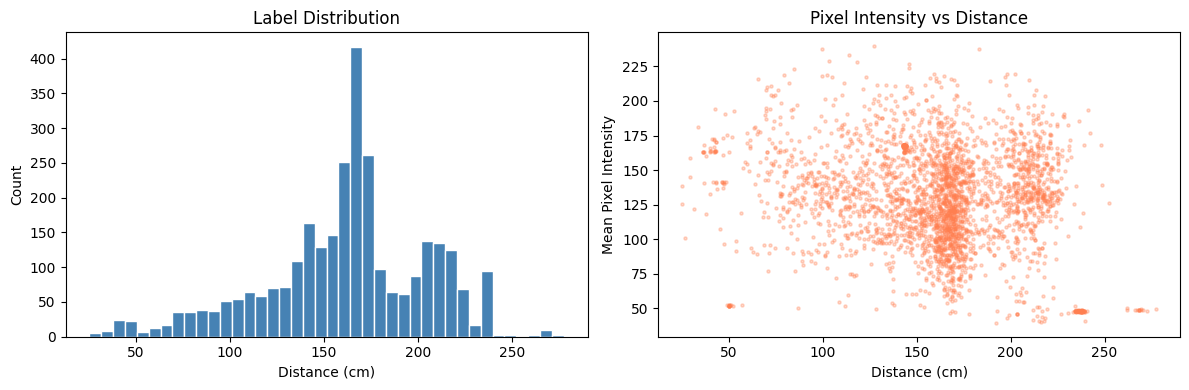

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Label distribution
axes[0].hist(distances * 100, bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Distance (cm)')
axes[0].set_ylabel('Count')
axes[0].set_title('Label Distribution')

# Mean pixel intensity vs distance
mean_intensity = images.mean(axis=1)
axes[1].scatter(distances * 100, mean_intensity, alpha=0.3, s=5, color='coral')
axes[1].set_xlabel('Distance (cm)')
axes[1].set_ylabel('Mean Pixel Intensity')
axes[1].set_title('Pixel Intensity vs Distance')

plt.tight_layout()
plt.show()

## **4. <u>ML Model Implementation</u>**
Implement preprocessing, model training, data split and evaluation.

**4.1. <u>Creating Splits</u>**

train (70%) | val (15%) | test (15%)

Why three splits?
* train  â†’ the model learns from this
* val    â†’ we tune hyperparameters on this (never used for fitting)
* test   â†’ final local evaluation; simulates the private Kaggle set
* random_state=42 keeps the split identical every run (reproducibility)

**FIX**: Splits are now applied to `X_all` (engineered features), not raw `images`.

In [13]:
# Split on X_all (engineered features), not raw images
# First split off the test set (15%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
        X_all, distances,
        test_size=0.15,
        random_state=42)

# Then split the remaining 85% into train (~70%) and val (~15%)
# 0.15 / 0.85 â‰ˆ 0.176 â†’ gives ~15% of total as validation
X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval,
        test_size=0.176,
        random_state=42)

print(f"[INFO]: Split sizes â€” train: {len(X_train)}, "
      f"val: {len(X_val)}, test: {len(X_test)}")

[INFO]: Split sizes â€” train: 2101, val: 449, test: 450


In [14]:
# â”€â”€ Preprocessing â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Strategy: scale all features, then let each model handle dimensionality:
#   â€¢ HGBR / ExtraTrees  â†’ trained directly on scaled features (handles high-dim natively)
#   â€¢ KNN                â†’ wrapped in a Pipeline that applies PCA first

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train only
X_val_scaled   = scaler.transform(X_val)          # transform only
X_test_scaled  = scaler.transform(X_test)         # transform only

print(f"[INFO]: Scaling done. Feature shape: {X_train_scaled.shape}")
print(f"        Mean (train, first 5): {X_train_scaled.mean(axis=0)[:5].round(4)}")
print(f"        Std  (train, first 5): {X_train_scaled.std(axis=0)[:5].round(4)}")

[INFO]: Scaling done. Feature shape: (2101, 4521)
        Mean (train, first 5): [-0. -0.  0. -0. -0.]
        Std  (train, first 5): [1. 1. 1. 1. 1.]


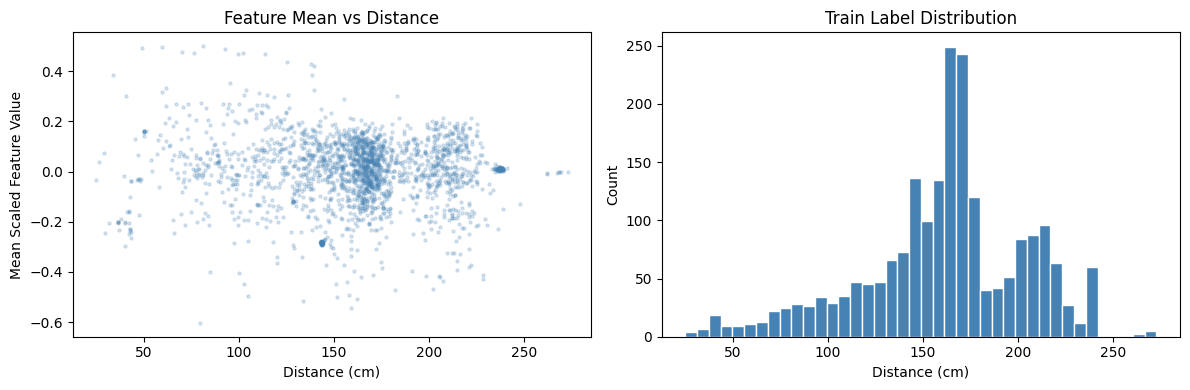

[INFO]: Training on 4521 features per sample.


In [18]:
# Quick depth-cue sanity check: mean pixel intensity vs distance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

mean_intensity = X_train_scaled.mean(axis=1)
axes[0].scatter(y_train * 100, mean_intensity, alpha=0.2, s=5, color='steelblue')
axes[0].set_xlabel('Distance (cm)')
axes[0].set_ylabel('Mean Scaled Feature Value')
axes[0].set_title('Feature Mean vs Distance')

axes[1].hist(y_train * 100, bins=40, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Distance (cm)')
axes[1].set_ylabel('Count')
axes[1].set_title('Train Label Distribution')

plt.tight_layout()
plt.show()
print(f"[INFO]: Training on {X_train_scaled.shape[1]} features per sample.")

## **5. Progressive Model Training**

Each tier is **tuned on the validation set** before we move to the next level. The key question at every step: *did the added complexity earn its keep?*

In [15]:
print('=' * 60)
print('  TIER 0 — NAIVE BASELINE (Sanity Floor)')
print('=' * 60)
print('Any real model must beat this. Zero learning involved.\n')

naive = DummyRegressor(strategy='mean')
naive.fit(X_train_scaled, y_train)
mae_naive = mean_absolute_error(y_val, naive.predict(X_val_scaled)) * 100
print(f'  Mean predictor -- Val MAE: {mae_naive:.2f} cm')

all_results = {'Naive (T0)': mae_naive}

  TIER 0 — NAIVE BASELINE (Sanity Floor)
Any real model must beat this. Zero learning involved.

  Mean predictor -- Val MAE: 33.58 cm


In [16]:
print('=' * 60)
print('  TIER 1 — RIDGE REGRESSION  (Linear Baseline)')
print('=' * 60)
print('Grid: n_pca in [50,100,200]  x  alpha in [0.01,0.1,1,10,100]\n')

import time
t0 = time.time()
best_ridge_mae = float('inf')
best_n_pca_r, best_alpha_r = 50, 1.0

for n_pca in [50, 100, 200]:
    for alpha in [0.01, 0.1, 1.0, 10.0, 100.0]:
        pipe = Pipeline([
            ('pca',   PCA(n_components=n_pca, random_state=42)),
            ('ridge', Ridge(alpha=alpha)),
        ])
        pipe.fit(X_train_scaled, y_train)
        mae = mean_absolute_error(y_val, pipe.predict(X_val_scaled)) * 100
        if mae < best_ridge_mae:
            best_ridge_mae = mae
            best_n_pca_r, best_alpha_r = n_pca, alpha

best_ridge = Pipeline([
    ('pca',   PCA(n_components=best_n_pca_r, random_state=42)),
    ('ridge', Ridge(alpha=best_alpha_r)),
])
best_ridge.fit(X_train_scaled, y_train)
val_pred_ridge = best_ridge.predict(X_val_scaled)
mae_ridge = mean_absolute_error(y_val, val_pred_ridge) * 100
r2_ridge  = r2_score(y_val, val_pred_ridge) * 100

print(f'  Best: n_pca={best_n_pca_r}, alpha={best_alpha_r}')
print(f'  Ridge -- Val MAE: {mae_ridge:.2f} cm  |  R²: {r2_ridge:.1f}%')
print(f'  Δ vs Naive: {mae_naive - mae_ridge:+.2f} cm  |  Time: {time.time()-t0:.1f}s')

all_results['Ridge (T1)'] = mae_ridge

  TIER 1 — RIDGE REGRESSION  (Linear Baseline)
Grid: n_pca in [50,100,200]  x  alpha in [0.01,0.1,1,10,100]

  Best: n_pca=200, alpha=100.0
  Ridge -- Val MAE: 20.22 cm  |  R²: 60.8%
  Δ vs Naive: +13.36 cm  |  Time: 17.3s


In [17]:
print('=' * 60)
print('  TIER 2 — K-NEAREST NEIGHBOURS  (Non-linear, Distance-based)')
print('=' * 60)
print('Grid: n_pca in [100,200]  x  k in [3,5,7,10,15]  x  weights\n')

t0 = time.time()
best_knn_mae = float('inf')
best_k_knn, best_w_knn, best_pca_knn = 5, 'distance', 200

for n_pca in [100, 200]:
    for k in [3, 5, 7, 10, 15]:
        for w in ['uniform', 'distance']:
            pipe = Pipeline([
                ('pca', PCA(n_components=n_pca, random_state=42)),
                ('knn', KNeighborsRegressor(n_neighbors=k, weights=w, n_jobs=-1)),
            ])
            pipe.fit(X_train_scaled, y_train)
            mae = mean_absolute_error(y_val, pipe.predict(X_val_scaled)) * 100
            if mae < best_knn_mae:
                best_knn_mae = mae
                best_k_knn, best_w_knn, best_pca_knn = k, w, n_pca

best_knn = Pipeline([
    ('pca', PCA(n_components=best_pca_knn, random_state=42)),
    ('knn', KNeighborsRegressor(n_neighbors=best_k_knn, weights=best_w_knn, n_jobs=-1)),
])
best_knn.fit(X_train_scaled, y_train)
val_pred_knn = best_knn.predict(X_val_scaled)
mae_knn = mean_absolute_error(y_val, val_pred_knn) * 100
r2_knn  = r2_score(y_val, val_pred_knn) * 100

print(f'  Best: n_pca={best_pca_knn}, k={best_k_knn}, weights={best_w_knn!r}')
print(f'  KNN  -- Val MAE: {mae_knn:.2f} cm  |  R²: {r2_knn:.1f}%')
print(f'  Δ vs Ridge: {mae_ridge - mae_knn:+.2f} cm  |  Time: {time.time()-t0:.1f}s')

all_results['KNN (T2)'] = mae_knn

  TIER 2 — K-NEAREST NEIGHBOURS  (Non-linear, Distance-based)
Grid: n_pca in [100,200]  x  k in [3,5,7,10,15]  x  weights

  Best: n_pca=100, k=3, weights='distance'
  KNN  -- Val MAE: 13.28 cm  |  R²: 74.6%
  Δ vs Ridge: +6.94 cm  |  Time: 26.9s


In [18]:
print('=' * 60)
print('  TIER 3 — DECISION TREE  (Non-linear, Interpretable)')
print('=' * 60)
print('Grid: max_depth in [5,8,10,15,20,None]  x  min_samples_leaf in [5,10,20]\n')

t0 = time.time()
best_dt_mae = float('inf')
best_depth, best_leaf = 10, 10

for max_d in [5, 8, 10, 15, 20, None]:
    for min_s in [5, 10, 20]:
        dt = DecisionTreeRegressor(max_depth=max_d, min_samples_leaf=min_s, random_state=42)
        dt.fit(X_train_scaled, y_train)
        mae = mean_absolute_error(y_val, dt.predict(X_val_scaled)) * 100
        if mae < best_dt_mae:
            best_dt_mae = mae
            best_depth, best_leaf = max_d, min_s

best_dt = DecisionTreeRegressor(max_depth=best_depth, min_samples_leaf=best_leaf, random_state=42)
best_dt.fit(X_train_scaled, y_train)
val_pred_dt = best_dt.predict(X_val_scaled)
mae_dt = mean_absolute_error(y_val, val_pred_dt) * 100
r2_dt  = r2_score(y_val, val_pred_dt) * 100

print(f'  Best: max_depth={best_depth}, min_samples_leaf={best_leaf}')
print(f'  DTree -- Val MAE: {mae_dt:.2f} cm  |  R²: {r2_dt:.1f}%')
print(f'  Δ vs KNN: {mae_knn - mae_dt:+.2f} cm  |  Time: {time.time()-t0:.1f}s')

all_results['Decision Tree (T3)'] = mae_dt

  TIER 3 — DECISION TREE  (Non-linear, Interpretable)
Grid: max_depth in [5,8,10,15,20,None]  x  min_samples_leaf in [5,10,20]

  Best: max_depth=10, min_samples_leaf=5
  DTree -- Val MAE: 23.10 cm  |  R²: 40.2%
  Δ vs KNN: -9.82 cm  |  Time: 419.5s


In [ ]:
print('=' * 60)
print('  TIER 4 — RANDOM FOREST  (Bagging Ensemble)')
print('=' * 60)
print('Grid: n_est in [50,100,200]  x  max_depth in [20,None]  x  min_leaf in [3,5]\n')

t0 = time.time()
best_rf_mae = float('inf')
best_rf_n, best_rf_d, best_rf_s = 100, None, 3

for n_est in [50, 100, 200]:
    for max_d in [20, None]:
        for min_s in [3, 5]:
            rf = RandomForestRegressor(
                n_estimators=n_est, max_depth=max_d,
                min_samples_leaf=min_s, n_jobs=-1, random_state=42)
            rf.fit(X_train_scaled, y_train)
            mae = mean_absolute_error(y_val, rf.predict(X_val_scaled)) * 100
            if mae < best_rf_mae:
                best_rf_mae = mae
                best_rf_n, best_rf_d, best_rf_s = n_est, max_d, min_s

best_rf = RandomForestRegressor(
    n_estimators=best_rf_n, max_depth=best_rf_d,
    min_samples_leaf=best_rf_s, n_jobs=-1, random_state=42)
best_rf.fit(X_train_scaled, y_train)
val_pred_rf = best_rf.predict(X_val_scaled)
mae_rf = mean_absolute_error(y_val, val_pred_rf) * 100
r2_rf  = r2_score(y_val, val_pred_rf) * 100

print(f'  Best: n_est={best_rf_n}, max_depth={best_rf_d}, min_leaf={best_rf_s}')
print(f'  RF   -- Val MAE: {mae_rf:.2f} cm  |  R²: {r2_rf:.1f}%')
print(f'  Δ vs DTree: {mae_dt - mae_rf:+.2f} cm  |  Time: {time.time()-t0:.1f}s')

# Feature group importance breakdown
n_ch = 3 if config['load_rgb'] else 1
n_color_f   = n_ch * 32
n_spatial_f = 69
n_hog_f     = X_train_scaled.shape[1] - n_spatial_f - n_color_f
imp = best_rf.feature_importances_
print(f'\n  Feature group importance:')
print(f'    HOG     ({n_hog_f} feats): {imp[:n_hog_f].sum()*100:.1f}%')
print(f'    Spatial ({n_spatial_f} feats): {imp[n_hog_f:n_hog_f+n_spatial_f].sum()*100:.1f}%')
print(f'    Color   ({n_color_f} feats): {imp[n_hog_f+n_spatial_f:].sum()*100:.1f}%')

all_results['Random Forest (T4)'] = mae_rf

  TIER 4 — RANDOM FOREST  (Bagging Ensemble)
Grid: n_est in [50,100,200]  x  max_depth in [20,None]  x  min_leaf in [3,5]



In [ ]:
print('=' * 60)
print('  TIER 5 — EXTRA TREES  (Randomised Bagging)')
print('=' * 60)
print('Like RF but splits are fully random => less variance, faster.\n')
print('Grid: n_est in [200,400]  x  min_leaf in [3,5]\n')

t0 = time.time()
best_etr_mae = float('inf')
best_etr_n, best_etr_s = 200, 3

for n_est in [200, 400]:
    for min_s in [3, 5]:
        etr = ExtraTreesRegressor(
            n_estimators=n_est, min_samples_leaf=min_s, n_jobs=-1, random_state=42)
        etr.fit(X_train_scaled, y_train)
        mae = mean_absolute_error(y_val, etr.predict(X_val_scaled)) * 100
        if mae < best_etr_mae:
            best_etr_mae = mae
            best_etr_n, best_etr_s = n_est, min_s

best_etr = ExtraTreesRegressor(
    n_estimators=best_etr_n, min_samples_leaf=best_etr_s, n_jobs=-1, random_state=42)
best_etr.fit(X_train_scaled, y_train)
val_pred_etr = best_etr.predict(X_val_scaled)
mae_etr = mean_absolute_error(y_val, val_pred_etr) * 100
r2_etr  = r2_score(y_val, val_pred_etr) * 100

print(f'  Best: n_est={best_etr_n}, min_leaf={best_etr_s}')
print(f'  ETR  -- Val MAE: {mae_etr:.2f} cm  |  R²: {r2_etr:.1f}%')
print(f'  Δ vs RF: {mae_rf - mae_etr:+.2f} cm  |  Time: {time.time()-t0:.1f}s')

all_results['ExtraTrees (T5)'] = mae_etr

In [ ]:
print('=' * 60)
print('  TIER 6 — HISTOGRAM GRADIENT BOOSTING REGRESSOR')
print('=' * 60)
print('Sequential boosting: each tree corrects the previous residuals.\n')

# 6a: light settings — quick sanity check
print('  6a) Light (100 iters, lr=0.1):')
t0 = time.time()
hgbr_light = HistGradientBoostingRegressor(
    learning_rate=0.1, max_iter=100, max_depth=6,
    min_samples_leaf=20, random_state=42)
hgbr_light.fit(X_train_scaled, y_train)
mae_hgbr_light = mean_absolute_error(y_val, hgbr_light.predict(X_val_scaled)) * 100
print(f'     HGBR light -- Val MAE: {mae_hgbr_light:.2f} cm  |  Time: {time.time()-t0:.1f}s')

# 6b: tuned settings — deeper trees, more iters, early stopping
print('  6b) Tuned (400 iters max, early stop, lr=0.05):')
t0 = time.time()
best_hgbr = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=400,
    max_depth=8,
    min_samples_leaf=10,
    l2_regularization=0.1,
    max_leaf_nodes=63,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42,
)
best_hgbr.fit(X_train_scaled, y_train)
val_pred_hgbr = best_hgbr.predict(X_val_scaled)
mae_hgbr = mean_absolute_error(y_val, val_pred_hgbr) * 100
r2_hgbr  = r2_score(y_val, val_pred_hgbr) * 100
print(f'     HGBR tuned -- Val MAE: {mae_hgbr:.2f} cm  |  R²: {r2_hgbr:.1f}%  |  Time: {time.time()-t0:.1f}s')
print(f'     Δ light→tuned: {mae_hgbr_light - mae_hgbr:+.2f} cm')
print(f'     Δ vs ETR:      {mae_etr - mae_hgbr:+.2f} cm')

all_results['HGBR light (T6a)'] = mae_hgbr_light
all_results['HGBR tuned (T6b)'] = mae_hgbr

In [ ]:
print('=' * 60)
print('  TIER 7 — HGBC SOFT CLASSIFIER  (Classification-as-Regression)')
print('=' * 60)
print('Bins distances into ordinal classes; E[y] = sum(P(class) * bin_centre).\n')

class SoftHGBClassifier(BaseEstimator, RegressorMixin):
    def __init__(self, n_bins=30, learning_rate=0.05, max_iter=400,
                 max_depth=8, min_samples_leaf=10, l2_regularization=0.1,
                 max_leaf_nodes=63, random_state=42):
        self.n_bins = n_bins
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.l2_regularization = l2_regularization
        self.max_leaf_nodes = max_leaf_nodes
        self.random_state = random_state

    def fit(self, X, y):
        _, self.bin_edges_ = np.histogram(y, bins=self.n_bins)
        self.bin_centers_ = 0.5 * (self.bin_edges_[:-1] + self.bin_edges_[1:])
        y_cls = np.digitize(y, self.bin_edges_[1:-1])
        self.clf_ = HistGradientBoostingClassifier(
            learning_rate=self.learning_rate, max_iter=self.max_iter,
            max_depth=self.max_depth, min_samples_leaf=self.min_samples_leaf,
            l2_regularization=self.l2_regularization,
            max_leaf_nodes=self.max_leaf_nodes, random_state=self.random_state)
        self.clf_.fit(X, y_cls)
        return self

    def predict(self, X):
        proba = self.clf_.predict_proba(X)
        return proba @ self.bin_centers_[self.clf_.classes_]

t0 = time.time()
hgbc = SoftHGBClassifier(n_bins=30, random_state=42)
hgbc.fit(X_train_scaled, y_train)
val_pred_hgbc = hgbc.predict(X_val_scaled)
mae_hgbc = mean_absolute_error(y_val, val_pred_hgbc) * 100
r2_hgbc  = r2_score(y_val, val_pred_hgbc) * 100
print(f'  HGBC (soft) -- Val MAE: {mae_hgbc:.2f} cm  |  R²: {r2_hgbc:.1f}%  |  Time: {time.time()-t0:.1f}s')
print(f'  Δ vs HGBR tuned: {mae_hgbr - mae_hgbc:+.2f} cm')

all_results['HGBC soft (T7)'] = mae_hgbc

In [ ]:
print('=' * 60)
print('  TIER 8 — MLP NEURAL NETWORK  (PCA + MLP)')
print('=' * 60)
print('Non-linear function approximator; PCA keeps training stable.\n')

t0 = time.time()
mlp_pipe = Pipeline([
    ('pca', PCA(n_components=50, random_state=42)),
    ('mlp', MLPRegressor(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu',
        learning_rate_init=0.001,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=42,
    )),
])
mlp_pipe.fit(X_train_scaled, y_train)
val_pred_mlp = mlp_pipe.predict(X_val_scaled)
mae_mlp = mean_absolute_error(y_val, val_pred_mlp) * 100
r2_mlp  = r2_score(y_val, val_pred_mlp) * 100
print(f'  MLP  -- Val MAE: {mae_mlp:.2f} cm  |  R²: {r2_mlp:.1f}%  |  Time: {time.time()-t0:.1f}s')
print(f'  Δ vs HGBC: {mae_hgbc - mae_mlp:+.2f} cm')

all_results['MLP (T8)'] = mae_mlp

In [ ]:
print('=' * 60)
print('  TIER 9 — STACKING ENSEMBLE  (Meta-learner)')
print('=' * 60)
print('Base learners: HGBR + ETR + KNN + MLP + HGBC.')
print('Meta-learner (HGBR) learns to correct their combined mistakes.\n')

t0 = time.time()
stack = StackingRegressor(
    estimators=[
        ('hgbr', best_hgbr),
        ('etr',  ExtraTreesRegressor(n_estimators=best_etr_n, min_samples_leaf=best_etr_s,
                                     n_jobs=-1, random_state=42)),
        ('knn',  best_knn),
        ('mlp',  mlp_pipe),
        ('hgbc', SoftHGBClassifier(n_bins=30, random_state=42)),
    ],
    final_estimator=HistGradientBoostingRegressor(
        max_iter=200, learning_rate=0.05, max_depth=5, random_state=42),
    cv=5,
    passthrough=True,
    n_jobs=-1,
)
stack.fit(X_train_scaled, y_train)
val_pred_stack = stack.predict(X_val_scaled)
mae_stack = mean_absolute_error(y_val, val_pred_stack) * 100
r2_stack  = r2_score(y_val, val_pred_stack) * 100
print(f'  Stacking -- Val MAE: {mae_stack:.2f} cm  |  R²: {r2_stack:.1f}%  |  Time: {time.time()-t0:.1f}s')
print(f'  Δ vs best single: {min(mae_hgbr, mae_hgbc, mae_etr) - mae_stack:+.2f} cm')

all_results['Stacking (T9)'] = mae_stack

In [ ]:
# --- Complexity-ladder visualisation ---
fig, ax = plt.subplots(figsize=(13, 6))

tiers  = list(all_results.keys())
maes   = list(all_results.values())
colors = ['#9e9e9e']  # tier 0 is grey (baseline)
prev   = maes[0]
for m in maes[1:]:
    colors.append('#4caf50' if m < prev else '#f44336')
    prev = m

bars = ax.bar(tiers, maes, color=colors, edgecolor='white', linewidth=0.8)
ax.axhline(28, color='orange', linestyle='--', linewidth=1.5, label='Grade 1.0 (28 cm)')
ax.axhline(18, color='gold',   linestyle='--', linewidth=1.5, label='Grade 4.0 (18 cm)')
ax.axhline(8,  color='limegreen', linestyle='--', linewidth=1.5, label='Grade 6.0 (8 cm)')
ax.set_ylabel('Val MAE (cm)')
ax.set_title('Complexity Ladder: Val MAE per Tier\n(green = improvement over previous tier, red = regression)')
ax.legend()
ax.tick_params(axis='x', rotation=40)
for bar, val in zip(bars, maes):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val:.1f}',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print('\nFull results table:')
print(f'  {"Model":<28}  {"Val MAE":>10}')
print('  ' + '-' * 42)
for name, mae in all_results.items():
    print(f'  {name:<28}  {mae:>8.2f} cm')

In [ ]:
# -- Pick best model, evaluate on held-out test set, generate submission --
best_model_name = min(all_results, key=all_results.get)
print(f'Best model: {best_model_name}  (Val MAE: {all_results[best_model_name]:.2f} cm)')

model_map = {
    'Ridge (T1)':          best_ridge,
    'KNN (T2)':            best_knn,
    'Decision Tree (T3)':  best_dt,
    'Random Forest (T4)':  best_rf,
    'ExtraTrees (T5)':     best_etr,
    'HGBR light (T6a)':    hgbr_light,
    'HGBR tuned (T6b)':    best_hgbr,
    'HGBC soft (T7)':      hgbc,
    'MLP (T8)':            mlp_pipe,
    'Stacking (T9)':       stack,
}
final_model = model_map.get(best_model_name, best_hgbr)

# Local test evaluation
test_pred = final_model.predict(X_test_scaled)
mae_test  = mean_absolute_error(y_test, test_pred) * 100
r2_test   = r2_score(y_test, test_pred) * 100
print(f'Local Test -- MAE: {mae_test:.2f} cm  |  R²: {r2_test:.1f}%')

# Retrain on full labelled dataset
X_all_scaled = scaler.fit_transform(X_all)
final_model.fit(X_all_scaled, distances)
print('Retrained on full labelled dataset.')

# Generate Kaggle submission
kaggle_images_raw = load_test_dataset(config)
kaggle_images_raw = np.array(kaggle_images_raw)
kaggle_features   = get_cached_features(kaggle_images_raw, config, 'test')
kaggle_scaled     = scaler.transform(kaggle_features)
kaggle_pred       = final_model.predict(kaggle_scaled)
save_results(kaggle_pred)
print(f'Saved prediction.csv with {len(kaggle_pred)} predictions')
print(f'Range: {kaggle_pred.min():.2f} m – {kaggle_pred.max():.2f} m')